# Programming Tutorial 5: Training Diagnosis and Techniques

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```


## Overview

Sections:
- Training diagnosis
  - Visualization
  - Training function
- Training stability
  - Data batching
  - Data standardization
  - Vanishing gradient effect
  - Parameter initialization
  - Optimization methods
- Overfitting and underfitting
  - Diagnose overfitting
  - Diagnose underfitting
  - Early stopping
  - Checkpoint saving
  - L2 regularization


Objectives:
- Learn how to diagnose model training issues
- Learn how to perform early stopping, saving checkpoints, and applying L2 loss
- Experiment with different training setups such as data standardization, parameter initialization, and optimization

## Training Diagnosis

In practice, one of the most common questions that comes up during model training is: *“How do I analyze my training results?”* This is an essential skill for developers and researchers because it directly affects decisions like:

- Should I keep training this model?
- Is the model underfitting or overfitting?
- Should I add regularization?

To learn how to diagnose model training effectively, the number one skill is learning how to visualize your training behavior.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

### Visualization

In previous tutorials, we used `matplotlib` to plot curves and inspect model behavior. Today, we’ll build a simple visualizer that shows plots **side-by-side** for training vs. testing performance using:

- loss curves
- accuracy curves

By viewing these plots together, we can quickly understand what is happening during training and spot common issues such as unstable optimization, underfitting, and overfitting.

In [2]:
import matplotlib.pyplot as plt

def plot_loss_acc(training_curve):

    epochs = training_curve['epochs']
    losses_train = training_curve['losses_train']
    losses_test = training_curve['losses_test']
    acc_train = training_curve['acc_train']
    acc_test = training_curve['acc_test']

    # Create a figure and subplots
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

    # Plot Loss on the first subplot
    ax[0].plot(epochs, losses_train, label='Train set loss')
    ax[0].plot(epochs, losses_test, label='Test set loss')
    ax[0].set_title('Training Loss Over Epochs')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].grid(True)
    ax[0].legend()

    # Plot Accuracy on the second subplot
    ax[1].plot(epochs, acc_train, label='Train set accuracy')
    ax[1].plot(epochs, acc_test, label='Test set accuracy')
    ax[1].set_title('Training Accuracy Over Epochs')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

Let's test out this function! It's supposed to make two side-by-side subplots of loss and accuracy curves. Pass in some toy values and see the plots.

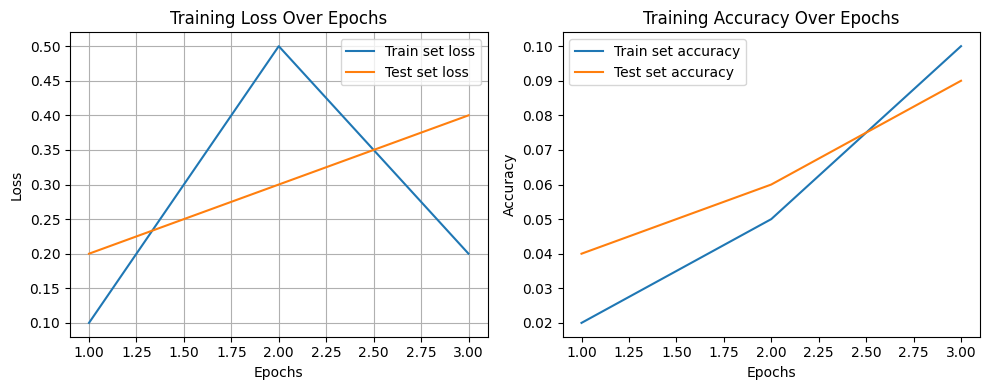

In [3]:
training_curve = {'epochs': [1, 2, 3],
                  'losses_train': [0.1, 0.5, 0.2],
                  'losses_test': [0.2, 0.3, 0.4],
                  'acc_train': [0.02, 0.05, 0.10],
                  'acc_test': [0.04, 0.06, 0.09]}

plot_loss_acc(training_curve)

### Training Function

To make experimentation easier, it also helps to wrap the training process into a reusable function. A clean training function allows you to quickly adjust model settings and try different training techniques, such as:

- enabling regularization methods
- switching optimization methods

For instance, instead of rewriting the same training loop every time, we can define a `train_model(...)` function that returns the loss and accuracy curves for both training and testing.

In [5]:
def train_model(model, optimizer, loss_function, dataset, n_epochs=10000, print_every=1000):

    # unpack dataset
    x_train, y_train, x_test, y_test = dataset

    # save epochs, losses and accuracies
    epochs = []
    losses_train = []
    losses_test = []
    acc_train = []
    acc_test = []

    for epoch in range(n_epochs):
        model.train()

        # forward and backpropagation on train
        logits = model(x_train)
        loss = loss_function(logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # compute loss and acc
        model.eval()
        with torch.no_grad():
            # train
            logits = model(x_train)
            train_loss = loss_function(logits, y_train).item()
            predicted_classes = torch.argmax(logits, dim=1)
            train_acc = (predicted_classes == y_train).float().mean().item()

            # test
            logits = model(x_test)
            test_loss = loss_function(logits, y_test).item()
            predicted_classes = torch.argmax(logits, dim=1)
            test_acc = (predicted_classes == y_test).float().mean().item()

        # print every print_every epochs
        if epoch % print_every == print_every - 1:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"train loss: {train_loss:.4f} | train acc (%): {train_acc*100:.2f} | "
                  f"test loss: {test_loss:.4f} | test acc (%): {test_acc*100:.2f}")

        # Save loss and accuracy
        epochs.append(epoch)
        losses_train.append(train_loss)
        losses_test.append(test_loss)
        acc_train.append(train_acc)
        acc_test.append(test_acc)

    # training curves for visualization
    training_curve = {'epochs': epochs,
                      'losses_train': losses_train,
                      'losses_test': losses_test,
                      'acc_train': acc_train,
                      'acc_test': acc_test}

    return model, training_curve

In [6]:
import torch

def train_model(model, optimizer, loss_function, dataset,
                n_epochs=10000, print_every=1000, batch_size=None):

    # unpack dataset
    x_train, y_train, x_test, y_test = dataset

    # default: full-batch training (keeps your current usage unchanged)
    if batch_size is None:
        batch_size = len(x_train)

    # save epochs, losses and accuracies
    epochs = []
    losses_train = []
    losses_test = []
    acc_train = []
    acc_test = []

    n_train = len(x_train)

    for epoch in range(n_epochs):
        model.train()

        # shuffle training data each epoch
        idx = torch.randperm(n_train)
        x_train_shuf = x_train[idx]
        y_train_shuf = y_train[idx]

        # mini-batch training
        for start in range(0, n_train, batch_size):
            end = start + batch_size
            xb = x_train_shuf[start:end]
            yb = y_train_shuf[start:end]

            logits = model(xb)
            loss = loss_function(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # compute loss and acc (evaluate on full train/test sets)
        model.eval()
        with torch.no_grad():
            # train
            logits_train = model(x_train)
            train_loss = loss_function(logits_train, y_train).item()
            pred_train = torch.argmax(logits_train, dim=1)
            train_acc = (pred_train == y_train).float().mean().item()

            # test
            logits_test = model(x_test)
            test_loss = loss_function(logits_test, y_test).item()
            pred_test = torch.argmax(logits_test, dim=1)
            test_acc = (pred_test == y_test).float().mean().item()

        # print every print_every epochs
        if epoch % print_every == print_every - 1:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"train loss: {train_loss:.4f} | train acc (%): {train_acc*100:.2f} | "
                  f"test loss: {test_loss:.4f} | test acc (%): {test_acc*100:.2f}")

        # save curves
        epochs.append(epoch + 1)
        losses_train.append(train_loss)
        losses_test.append(test_loss)
        acc_train.append(train_acc)
        acc_test.append(test_acc)

    training_curve = {
        'epochs': epochs,
        'losses_train': losses_train,
        'losses_test': losses_test,
        'acc_train': acc_train,
        'acc_test': acc_test
    }

    return model, training_curve

### Toy Dataset: Two Moons Dataset *(Coding Not Required)*

Let's use torch to create a dataset. This is the dataset we'll be using today to train the model and practice the training diagnoses techniques.

You do not need to know how to code the `make_two_moons` function. However, we encourage you to change the arguments `n` and `noise` and plot the dataset to observe what changes in your dataset.

In [7]:
import matplotlib.pyplot as plt
import math

def make_two_moons(n=1000, noise=0.1, seed=42):

    n1 = n // 2 # number of samples in moon 1
    n2 = n - n1 # number of samples in moon 2

    print(f"Generating {n1} samples for moon 1 and {n2} samples for moon 2.")

    # Set the random seed for reproducibility
    torch.manual_seed(seed)

    # Moon angles
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi

    # Generate moons
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), 1 - torch.sin(t2) - 0.5], dim=1)

    # Stack data
    X = torch.cat([x1, x2], dim=0)
    y = torch.cat([
        torch.zeros(n1, dtype=torch.long),
        torch.ones(n2, dtype=torch.long)
    ], dim=0)

    X = X + noise * torch.randn_like(X)

    idx = torch.randperm(n)
    return X[idx], y[idx]

# Visualize the dataset
def plot_dataset(X, y):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, alpha=0.8)
    plt.title("Two-Moons Toy Dataset")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

Generating 150 samples for moon 1 and 150 samples for moon 2.


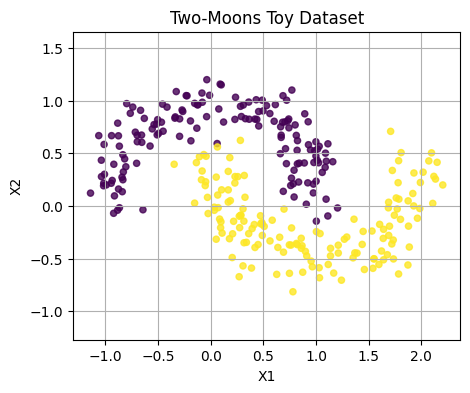

In [8]:
# Make dataset
X, y = make_two_moons(n=300, noise=0.15)
plot_dataset(X, y)

Today, we'll be using this Two Moons dataset for experiments! Let's split the dataset into 50% for training and 50% for testing:

In [9]:
x_train = X[:int(len(X)*0.5)]
y_train = y[:int(len(X)*0.5)]
x_test = X[int(len(X)*0.5):]
y_test = y[int(len(X)*0.5):]

print('Training input size: {}, output size: {}'.format(x_train.shape, y_train.shape))
print('Testing input size: {}, output size: {}'.format(x_test.shape, y_test.shape))

Training input size: torch.Size([150, 2]), output size: torch.Size([150])
Testing input size: torch.Size([150, 2]), output size: torch.Size([150])


### Toy Model: Multi-Layer Neural Network Classifier

Similarly, we need a model to train on the toy dataset. Let's create a simple multi-layer neural network classifier similar to the one we used in Programming Tutorial 2 for this task!

In [10]:
class MLPMultiClassClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(MLPMultiClassClassifier, self).__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

    self.linear1 = nn.Linear(self.input_size, hidden_size)
    self.activation1 = nn.Sigmoid()
    self.linear2 = nn.Linear(hidden_size, hidden_size)
    self.activation2 = nn.Sigmoid()
    self.linear3 = nn.Linear(hidden_size, self.output_size)

  def forward(self, x):
    linear1 = self.linear1(x)
    act1 = self.activation1(linear1)
    linear2 = self.linear2(act1)
    act2 = self.activation2(linear2)
    output = self.linear3(act2)
    return output

### Pipeline Testing

Let's test the training function and visualization function:

Epoch 50/200 | train loss: 0.6857 | train acc (%): 51.33 | test loss: 0.6862 | test acc (%): 48.67
Epoch 100/200 | train loss: 0.6800 | train acc (%): 56.67 | test loss: 0.6796 | test acc (%): 53.33
Epoch 150/200 | train loss: 0.6724 | train acc (%): 73.33 | test loss: 0.6709 | test acc (%): 76.00
Epoch 200/200 | train loss: 0.6617 | train acc (%): 75.33 | test loss: 0.6585 | test acc (%): 80.67


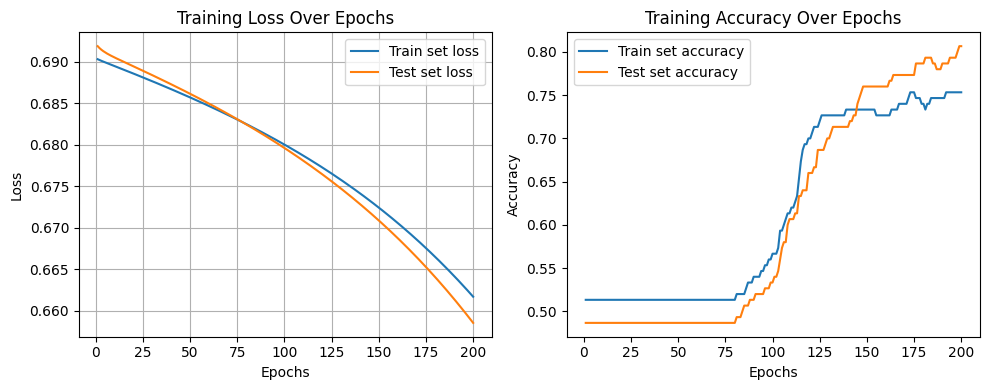

In [11]:
hidden_size = 16 # number of nodes in hidden layers

# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train, y_train, x_test, y_test),
    n_epochs=200,
    print_every=50
)

# plot all curves
plot_loss_acc(training_curve)

We are ready! Now, let's start training some models and learn about diagnosing problems and introducing solutions.

## Training Stability

We learned in the lecture that these three tools that dramatically affect convergence:

- Data standardization
- Parameter initialization
- Batching
- Optimization method

Now, let's try to implement them in our codes and compare the differences between the design choices!

### 1. Data Standardization

First, let's compare the training curves with vs. without data standardization. Create a dataset with large values:

Generating 150 samples for moon 1 and 150 samples for moon 2.


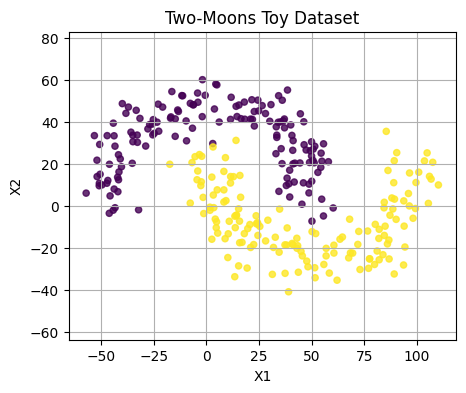

In [12]:
# create a dataset with large values
X, y = make_two_moons(n=300, noise=0.15)
X = X*50
plot_dataset(X, y)

In [13]:
x_train = X[:int(len(X)*0.5)]
y_train = y[:int(len(X)*0.5)]
x_test = X[int(len(X)*0.5):]
y_test = y[int(len(X)*0.5):]

To standardize the data, we need to calculate the mean and standard deviation values using the **train** set.

In [14]:
mean = x_train.mean(dim=0, keepdim=True)
std = x_train.std(dim=0, keepdim=True)

In [15]:
# Standardize data
x_train_std = (x_train - mean) / (std + 1e-8) # add a small value to prevent error
x_test_std  = (x_test  - mean) / (std + 1e-8) # add a small value to prevent error

**Model Training on Data Without Standardization:**

Epoch 1000/10000 | train loss: 0.6649 | train acc (%): 62.00 | test loss: 0.6703 | test acc (%): 54.67
Epoch 2000/10000 | train loss: 0.5754 | train acc (%): 88.00 | test loss: 0.5768 | test acc (%): 87.33
Epoch 3000/10000 | train loss: 0.4424 | train acc (%): 87.33 | test loss: 0.4374 | test acc (%): 88.00
Epoch 4000/10000 | train loss: 0.3710 | train acc (%): 87.33 | test loss: 0.3885 | test acc (%): 84.00
Epoch 5000/10000 | train loss: 0.3394 | train acc (%): 87.33 | test loss: 0.3607 | test acc (%): 84.00
Epoch 6000/10000 | train loss: 0.3248 | train acc (%): 87.33 | test loss: 0.3484 | test acc (%): 84.67
Epoch 7000/10000 | train loss: 0.3106 | train acc (%): 87.33 | test loss: 0.3458 | test acc (%): 85.33
Epoch 8000/10000 | train loss: 0.3006 | train acc (%): 88.00 | test loss: 0.3440 | test acc (%): 85.33
Epoch 9000/10000 | train loss: 0.2925 | train acc (%): 88.00 | test loss: 0.3452 | test acc (%): 86.00
Epoch 10000/10000 | train loss: 0.2855 | train acc (%): 88.00 | test loss

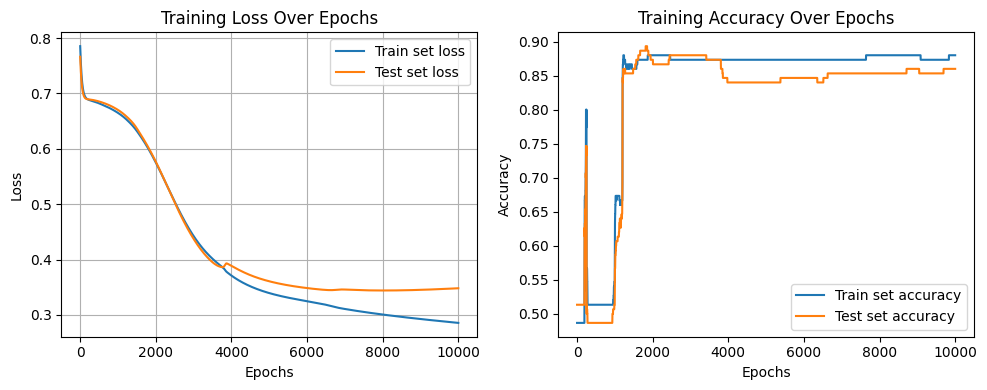

In [16]:
# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train, y_train, x_test, y_test),
    n_epochs=10000,
    print_every=1000,
)

# plot all curves
plot_loss_acc(training_curve)

**Model Training on Data With Standardization:**

Epoch 1000/10000 | train loss: 0.6875 | train acc (%): 51.33 | test loss: 0.6875 | test acc (%): 48.67
Epoch 2000/10000 | train loss: 0.6812 | train acc (%): 70.00 | test loss: 0.6803 | test acc (%): 63.33
Epoch 3000/10000 | train loss: 0.6677 | train acc (%): 76.00 | test loss: 0.6650 | test acc (%): 80.67
Epoch 4000/10000 | train loss: 0.6361 | train acc (%): 80.67 | test loss: 0.6299 | test acc (%): 82.67
Epoch 5000/10000 | train loss: 0.5656 | train acc (%): 80.67 | test loss: 0.5536 | test acc (%): 82.67
Epoch 6000/10000 | train loss: 0.4594 | train acc (%): 83.33 | test loss: 0.4418 | test acc (%): 86.00
Epoch 7000/10000 | train loss: 0.3768 | train acc (%): 86.00 | test loss: 0.3588 | test acc (%): 88.00
Epoch 8000/10000 | train loss: 0.3341 | train acc (%): 88.00 | test loss: 0.3215 | test acc (%): 86.67
Epoch 9000/10000 | train loss: 0.3147 | train acc (%): 87.33 | test loss: 0.3096 | test acc (%): 85.33
Epoch 10000/10000 | train loss: 0.3063 | train acc (%): 88.00 | test loss

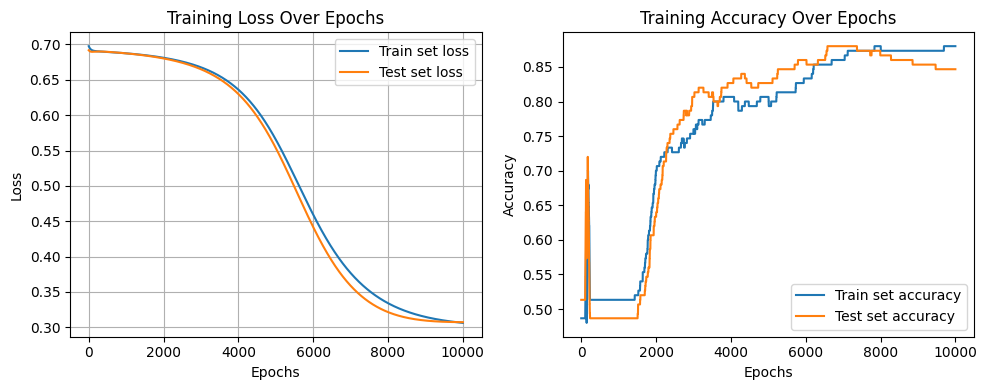

In [17]:
# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=10000,
    print_every=1000
)

# plot all curves
plot_loss_acc(training_curve)

We can see that the data **with** standardization lead to a smoother loss drop.

### 2. Vanishing Gradient

We learned in the lecture that for activation functions like sigmoid and tanh, the derivatives (gradients) become very small when the input `z` is far from 0.

As a recap, see the figures in the next cell for these activation functions:

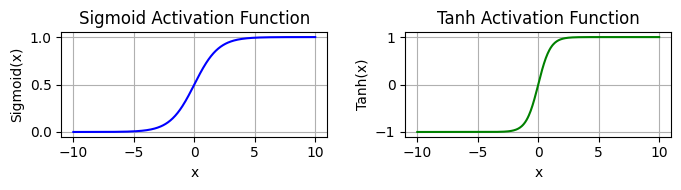

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 400)
sigmoid_values = sigmoid(x)
tanh_values = tanh(x)
fig, axs = plt.subplots(1, 2, figsize=(7, 2))

axs[0].plot(x, sigmoid_values, label="Sigmoid", color='blue')
axs[0].set_title("Sigmoid Activation Function")
axs[0].set_xlabel("x")
axs[0].set_ylabel("Sigmoid(x)")
axs[0].grid(True)

axs[1].plot(x, tanh_values, label="Tanh", color='green')
axs[1].set_title("Tanh Activation Function")
axs[1].set_xlabel("x")
axs[1].set_ylabel("Tanh(x)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

To see the vanishing gradient effect, we can **initialize a model with large parameters** and visualize the learning.

We'll start with customizing a binary classifier with assigned initialization range, `init_value`.

**Initializing a Layer**


In PyTorch, we can directly initialize the weights and bias of a layer using `torch.nn.init`. For example:
```
nn.init.uniform_(self.linear1.weight, a=-0.3, b=0.3)
nn.init.zeros_(self.linear1.bias)
```

This assigns the weight matrix using a uniform distribution and sets the bias to zeros.

**Initializing all layers efficiently**

Instead of writing initialization code for every layer manually, it’s more convenient to create a helper function that initializes all linear layers in the model using the same strategy. This makes it easy to swap initialization methods when running experiments.

Let’s start by building initialization functions based on the uniform distribution in a fixed range.

- `init_uniform`: initialize each linear layer using a fixed boundary range `[a, b]`.


In [19]:
def init_uniform(model, a=-0.3, b=0.3):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.uniform_(m.weight, a=a, b=b)
            nn.init.zeros_(m.bias)

If we initialize all parameters to be around 2000:

Epoch 300/3000 | train loss: 0.6092 | train acc (%): 70.67 | test loss: 0.6431 | test acc (%): 65.33
Epoch 600/3000 | train loss: 0.6052 | train acc (%): 70.67 | test loss: 0.6473 | test acc (%): 65.33
Epoch 900/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6483 | test acc (%): 65.33
Epoch 1200/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6485 | test acc (%): 65.33
Epoch 1500/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6485 | test acc (%): 65.33
Epoch 1800/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6486 | test acc (%): 65.33
Epoch 2100/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6487 | test acc (%): 65.33
Epoch 2400/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6487 | test acc (%): 65.33
Epoch 2700/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6487 | test acc (%): 65.33
Epoch 3000/3000 | train loss: 0.6051 | train acc (%): 70.67 | test loss: 0.6487 | tes

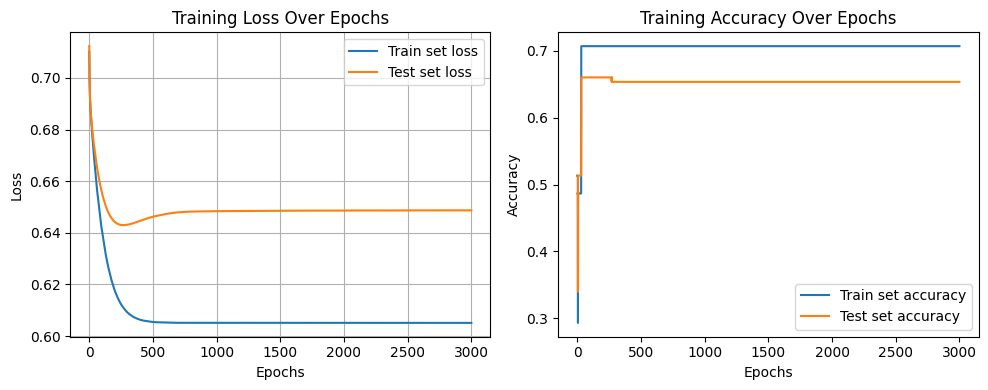

In [20]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_uniform(model, a=2000, b=2001) # large initialization

loss_function = nn.CrossEntropyLoss()
optimizer_random = optim.SGD(model.parameters(), lr=0.1)

model, curve_random = train_model(
    model=model,
    optimizer=optimizer_random,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=3000,
    print_every=300
)

plot_loss_acc(curve_random)

We observed that the model stopped learning. The losses froze.

#### **Visualization** *[No Coding Required]*

We can observe the vanishing gradient effect through the visualization of the following distributions:
- Gradient: The gradient will be close to zero if there is vanishing gradient effect in model training.
- Parameters: Large parameters might lead to gradients that are close to zero.
- Z values: Z values will be large if the parameters are large and inputs are non-zero
- Activations: When Z values are large, the output of `sigmoid` or `tanh` will be close to zero

To generate violin plots, we can use the visualization tool, [`seaborn`](https://seaborn.pydata.org/), which is a high-level plotting library built on top of `matplotlib`. Compared to raw `matplotlib`, `seaborn` makes it easier to create clean statistical plots (e.g., violin plots) with less code and better default styling.

You don't need to learn how to code the visualizer below.

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

class VisualizationHelper:
    def __init__(self):
        self.cols = ["epoch", "layer", "value"]

        # store rows first (avoid repeated pd.concat warnings)
        self._grad_rows = []
        self._param_rows = []
        self._z_rows = []
        self._act_rows = []

        self.gradients = None
        self.parameters = None
        self.z_values = None
        self.activations = None

        self._cache_z = {}
        self._cache_a = {}
        self._hooks = []

    def attach_hooks(self, model):
        for name, module in model.named_modules():
            if name == "":
                continue
            if module.__class__.__name__ == "Linear":
                self._hooks.append(module.register_forward_hook(self._make_hook(self._cache_z, name)))
            elif module.__class__.__name__ == "Sigmoid":
                self._hooks.append(module.register_forward_hook(self._make_hook(self._cache_a, name)))

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

    def _make_hook(self, cache, layer_name):
        def hook(module, inp, out):
            cache[layer_name] = out.detach()
        return hook

    def update_values(self, model, epoch):
        # weights + gradients
        for name, p in model.named_parameters():
            if ("weight" not in name) or (p.grad is None):
                continue
            g = p.grad.detach().flatten().cpu().numpy()
            w = p.detach().flatten().cpu().numpy()
            self._grad_rows += [[epoch, name, v] for v in g]
            self._param_rows += [[epoch, name, v] for v in w]

        # z-values
        for name, t in self._cache_z.items():
            vals = t.flatten().cpu().numpy()
            self._z_rows += [[epoch, name, v] for v in vals]

        # activations
        for name, t in self._cache_a.items():
            vals = t.flatten().cpu().numpy()
            self._act_rows += [[epoch, name, v] for v in vals]

    def finalize(self):
        self.gradients = pd.DataFrame(self._grad_rows, columns=self.cols)
        self.parameters = pd.DataFrame(self._param_rows, columns=self.cols)
        self.z_values = pd.DataFrame(self._z_rows, columns=self.cols)
        self.activations = pd.DataFrame(self._act_rows, columns=self.cols)

    def plot(self, figsize=(8, 3)):
        self.finalize()

        for title, data in [
            ("Gradients", self.gradients),
            ("Model Parameters", self.parameters),
            ("Z Values (Linear outputs)", self.z_values),
            ("Activations (Sigmoid outputs)", self.activations),
        ]:
            plt.figure(figsize=figsize)
            ax = sns.violinplot(data=data, x="layer", y="value", hue="epoch", cut=0)
            plt.title(title)
            plt.xticks(rotation=25, ha="right")
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="epoch")
            plt.tight_layout()
            plt.show()

def visualize_training(model, vis_epochs=5):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    vis = VisualizationHelper()
    vis.attach_hooks(model)

    for epoch in range(vis_epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(x_train_std)
        loss = loss_fn(logits, y_train)
        loss.backward()
        optimizer.step()
        vis.update_values(model, epoch+1)

    vis.remove_hooks()
    vis.plot()

**[Large Parameters]**

Visualize the distributions for 5 epochs:

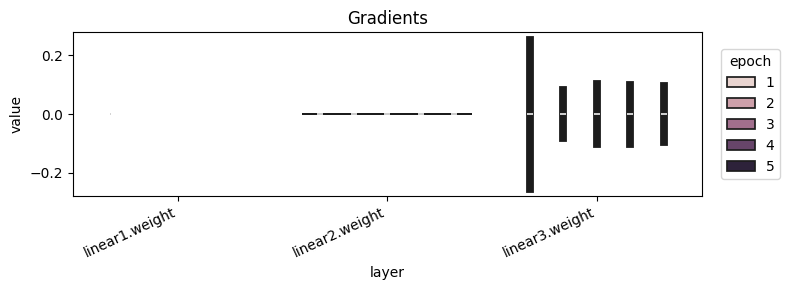

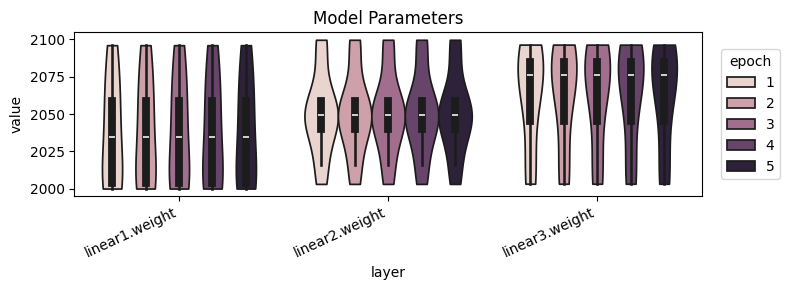

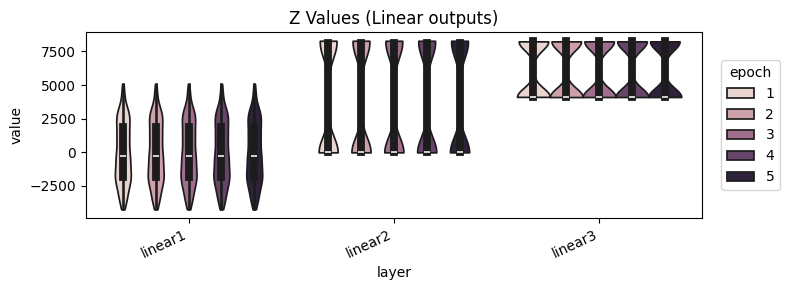

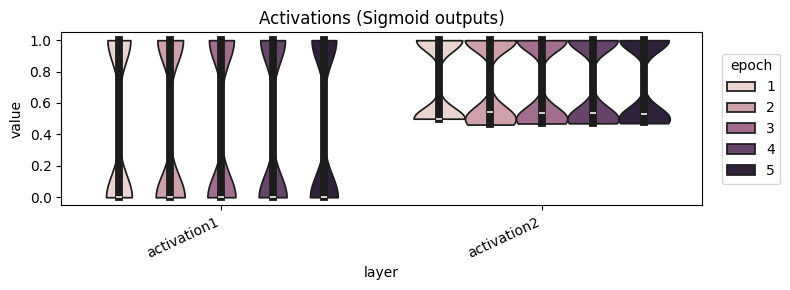

In [22]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_uniform(model, a=2000, b=2100) # large initialization

visualize_training(model, vis_epochs=5)

**[Zero Parameters]**

Using this visualization tool, we can also observe what happens when all parameters are zero:

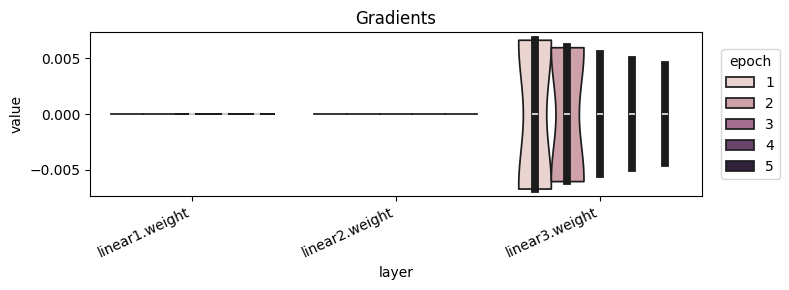

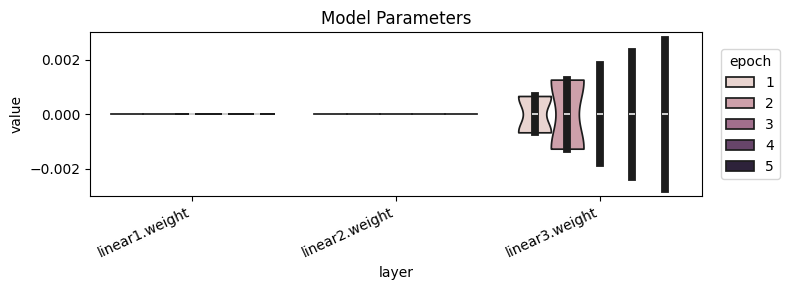

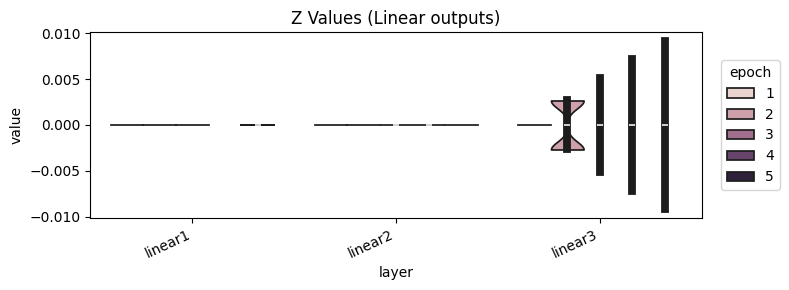

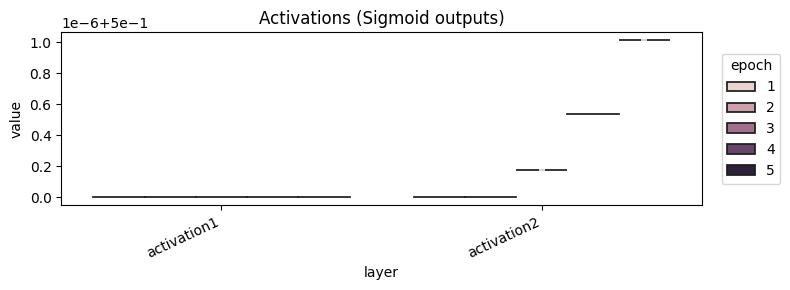

In [ ]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_uniform(model, a=0, b=0) # zero initialization

visualize_training(model, vis_epochs=5)

Zero-initialized parameters lead to zero `z` values, so there is no gradient.

### 3. Parameter Initialization

Even when we are not seeing extreme effect of vanishing gradient or zero gradient, the design choices for parameter initialization could still contribute to the stability of training.

In Lab 1, we experimented with different ways to randomly initialize model parameters. In this tutorial, we’ll take a closer look at **how the choice of initialization distribution and scale** can affect training behavior.

Specifically, we will compare two types of random initialization strategies:

- Hard-coded random initialization (fixed ranges or fixed standard deviations)
- Fan-in based random initialization (ranges or standard deviations based on the layer input size)

We’ll run this comparison using two common distributions:

- Uniform distribution
- Gaussian (Normal) distribution



To compare hard-coded to fan-in initialization, we will create the following functions:
- `init_uniform`: initialize each linear layer using a fixed boundary range `[a, b]`.
- `init_uniform_fanin`: initialize each linear layer using a boundary range based on the layer’s fan-in.

In the next part, we’ll implement the same idea using a Gaussian distribution, and then compare training curves across different initialization methods.

In [23]:
# uniform distribution
def init_uniform(model, a=-0.3, b=0.3):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.uniform_(m.weight, a=a, b=b)
            nn.init.zeros_(m.bias)

# add fan-in
def init_uniform_fanin(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)  # in_features
            bound = 1.0 / math.sqrt(fan_in)
            nn.init.uniform_(m.weight, -bound, bound)
            nn.init.zeros_(m.bias)

**Uniform Distribution: Hard-Coded**

Epoch 300/3000 | train loss: 0.6928 | train acc (%): 51.33 | test loss: 0.6942 | test acc (%): 48.67
Epoch 600/3000 | train loss: 0.6927 | train acc (%): 51.33 | test loss: 0.6942 | test acc (%): 48.67
Epoch 900/3000 | train loss: 0.6927 | train acc (%): 51.33 | test loss: 0.6941 | test acc (%): 48.67
Epoch 1200/3000 | train loss: 0.6925 | train acc (%): 51.33 | test loss: 0.6940 | test acc (%): 48.67
Epoch 1500/3000 | train loss: 0.6923 | train acc (%): 51.33 | test loss: 0.6937 | test acc (%): 48.67
Epoch 1800/3000 | train loss: 0.6914 | train acc (%): 51.33 | test loss: 0.6927 | test acc (%): 48.67
Epoch 2100/3000 | train loss: 0.6870 | train acc (%): 51.33 | test loss: 0.6880 | test acc (%): 48.67
Epoch 2400/3000 | train loss: 0.6356 | train acc (%): 81.33 | test loss: 0.6328 | test acc (%): 84.00
Epoch 2700/3000 | train loss: 0.3503 | train acc (%): 88.00 | test loss: 0.3349 | test acc (%): 87.33
Epoch 3000/3000 | train loss: 0.2995 | train acc (%): 88.00 | test loss: 0.3006 | tes

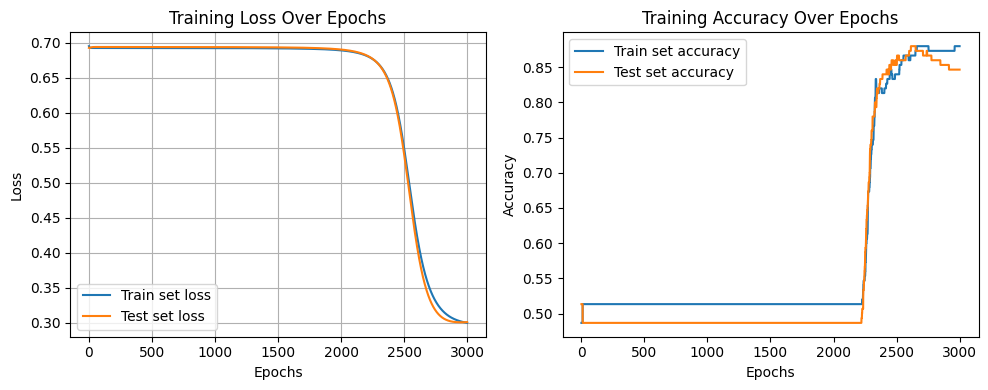

In [24]:
# initialize model parameters
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_uniform(model, a=-0.1, b=0.1) # uniform

loss_function = nn.CrossEntropyLoss()
optimizer_random = optim.SGD(model.parameters(), lr=0.1)

model, curve_random = train_model(
    model=model,
    optimizer=optimizer_random,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=3000,
    print_every=300
)

plot_loss_acc(curve_random)

**Uniform Distribution: Fan-in**

Epoch 300/3000 | train loss: 0.6915 | train acc (%): 51.33 | test loss: 0.6932 | test acc (%): 48.67
Epoch 600/3000 | train loss: 0.6815 | train acc (%): 51.33 | test loss: 0.6823 | test acc (%): 48.67
Epoch 900/3000 | train loss: 0.5402 | train acc (%): 86.00 | test loss: 0.5318 | test acc (%): 86.00
Epoch 1200/3000 | train loss: 0.3236 | train acc (%): 87.33 | test loss: 0.3155 | test acc (%): 86.00
Epoch 1500/3000 | train loss: 0.3012 | train acc (%): 88.00 | test loss: 0.3065 | test acc (%): 84.67
Epoch 1800/3000 | train loss: 0.2984 | train acc (%): 87.33 | test loss: 0.3072 | test acc (%): 84.67
Epoch 2100/3000 | train loss: 0.2971 | train acc (%): 87.33 | test loss: 0.3064 | test acc (%): 84.67
Epoch 2400/3000 | train loss: 0.2960 | train acc (%): 87.33 | test loss: 0.3051 | test acc (%): 84.67
Epoch 2700/3000 | train loss: 0.2950 | train acc (%): 87.33 | test loss: 0.3038 | test acc (%): 84.67
Epoch 3000/3000 | train loss: 0.2942 | train acc (%): 87.33 | test loss: 0.3025 | tes

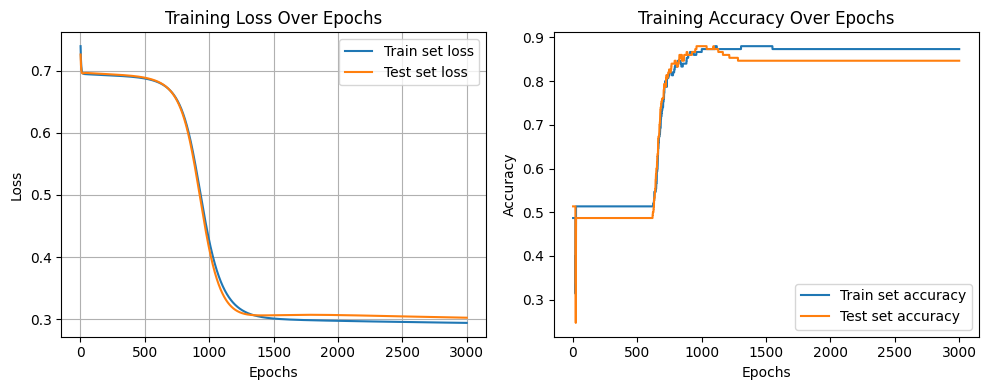

In [25]:
# initialize model parameters
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_uniform_fanin(model) # fan-in uniform

loss_function = nn.CrossEntropyLoss()
optimizer_random = optim.SGD(model.parameters(), lr=0.1)

model, curve_random = train_model(
    model=model,
    optimizer=optimizer_random,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=3000,
    print_every=300
)

plot_loss_acc(curve_random)

By comparing the training curves, we can see that fan-in based initialization often converges faster and more consistently than hard-coded random initialization. This is because the fan-in method automatically scales the weight magnitude based on the layer size, which helps stabilize gradients and makes optimization easier early in training.

Similar to the above experiment, let's write the functions to initialize parameters using normal distribution:

In [26]:
# normal distribution
def init_normal(model, mean=0.0, std=0.1):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=mean, std=std)
            nn.init.zeros_(m.bias)

# add fan-in
def init_normal_fanin(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            std = 1.0 / math.sqrt(fan_in)
            nn.init.normal_(m.weight, mean=0.0, std=std)
            nn.init.zeros_(m.bias)

**Normal Distribution: Hard-Coded**

Epoch 300/3000 | train loss: 0.6923 | train acc (%): 51.33 | test loss: 0.6936 | test acc (%): 48.67
Epoch 600/3000 | train loss: 0.6910 | train acc (%): 51.33 | test loss: 0.6923 | test acc (%): 48.67
Epoch 900/3000 | train loss: 0.6841 | train acc (%): 51.33 | test loss: 0.6849 | test acc (%): 48.67
Epoch 1200/3000 | train loss: 0.5930 | train acc (%): 84.00 | test loss: 0.5878 | test acc (%): 86.00
Epoch 1500/3000 | train loss: 0.3347 | train acc (%): 87.33 | test loss: 0.3239 | test acc (%): 86.67
Epoch 1800/3000 | train loss: 0.3018 | train acc (%): 88.00 | test loss: 0.3058 | test acc (%): 84.67
Epoch 2100/3000 | train loss: 0.2984 | train acc (%): 87.33 | test loss: 0.3069 | test acc (%): 84.67
Epoch 2400/3000 | train loss: 0.2972 | train acc (%): 87.33 | test loss: 0.3065 | test acc (%): 84.67
Epoch 2700/3000 | train loss: 0.2962 | train acc (%): 87.33 | test loss: 0.3054 | test acc (%): 84.67
Epoch 3000/3000 | train loss: 0.2954 | train acc (%): 87.33 | test loss: 0.3042 | tes

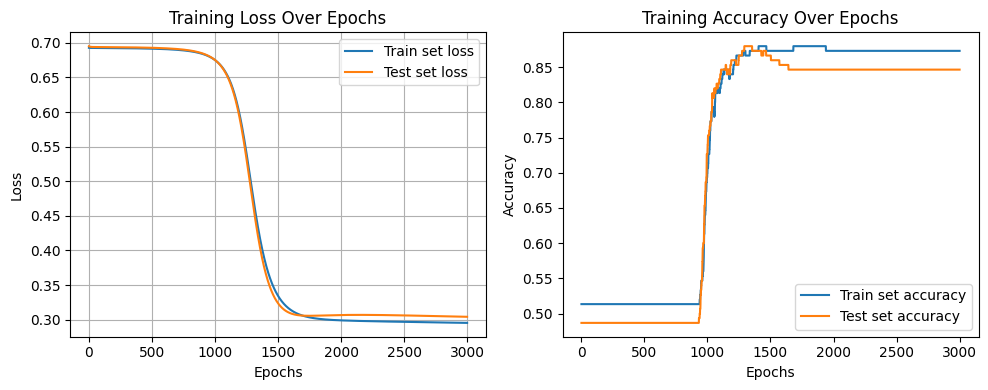

In [27]:
# initialize model parameters
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_normal(model, mean=0.0, std=0.1) # normal

loss_function = nn.CrossEntropyLoss()
optimizer_random = optim.SGD(model.parameters(), lr=0.1)

model, curve_random = train_model(
    model=model,
    optimizer=optimizer_random,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=3000,
    print_every=300
)

plot_loss_acc(curve_random)

**Normal Distribution: Fan-in**

Epoch 300/3000 | train loss: 0.4822 | train acc (%): 87.33 | test loss: 0.4811 | test acc (%): 84.67
Epoch 600/3000 | train loss: 0.3169 | train acc (%): 88.00 | test loss: 0.3140 | test acc (%): 84.67
Epoch 900/3000 | train loss: 0.3021 | train acc (%): 87.33 | test loss: 0.3080 | test acc (%): 84.67
Epoch 1200/3000 | train loss: 0.2990 | train acc (%): 87.33 | test loss: 0.3078 | test acc (%): 84.67
Epoch 1500/3000 | train loss: 0.2972 | train acc (%): 87.33 | test loss: 0.3066 | test acc (%): 84.67
Epoch 1800/3000 | train loss: 0.2958 | train acc (%): 87.33 | test loss: 0.3050 | test acc (%): 84.67
Epoch 2100/3000 | train loss: 0.2946 | train acc (%): 87.33 | test loss: 0.3035 | test acc (%): 84.67
Epoch 2400/3000 | train loss: 0.2936 | train acc (%): 87.33 | test loss: 0.3021 | test acc (%): 84.67
Epoch 2700/3000 | train loss: 0.2927 | train acc (%): 87.33 | test loss: 0.3008 | test acc (%): 84.67
Epoch 3000/3000 | train loss: 0.2919 | train acc (%): 87.33 | test loss: 0.2997 | tes

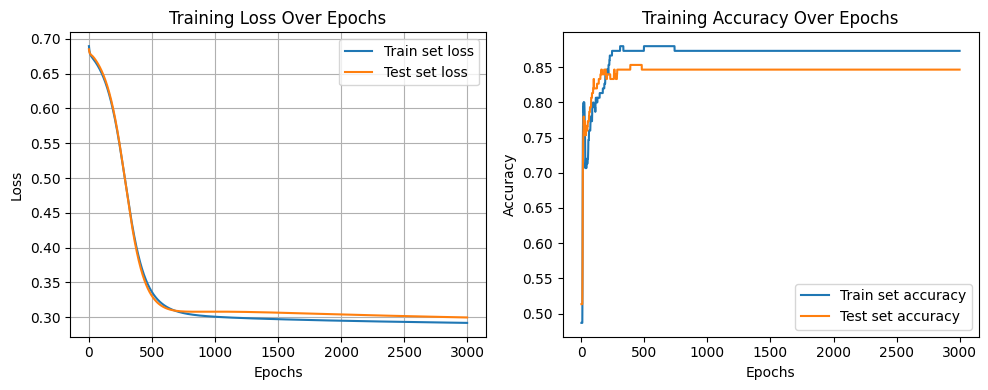

In [28]:
# initialize model parameters
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
init_normal_fanin(model) # fan-in normal

loss_function = nn.CrossEntropyLoss()
optimizer_random = optim.SGD(model.parameters(), lr=0.1)

model, curve_random = train_model(
    model=model,
    optimizer=optimizer_random,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=3000,
    print_every=300
)

plot_loss_acc(curve_random)

### 4. Batching

The batch size can also contribute to the stability of training. Let’s train the model using a small batch size (i.e., 1), a medium batch size (i.e., 16), and a large batch size (e.g., dataset size).

Epoch 50/500 | train loss: 0.3883 | train acc (%): 85.33 | test loss: 0.3740 | test acc (%): 84.00
Epoch 100/500 | train loss: 0.3866 | train acc (%): 85.33 | test loss: 0.3774 | test acc (%): 84.67
Epoch 150/500 | train loss: 0.3822 | train acc (%): 85.33 | test loss: 0.3744 | test acc (%): 84.67
Epoch 200/500 | train loss: 0.3845 | train acc (%): 85.33 | test loss: 0.3762 | test acc (%): 84.67
Epoch 250/500 | train loss: 0.3918 | train acc (%): 85.33 | test loss: 0.3912 | test acc (%): 85.33
Epoch 300/500 | train loss: 0.4024 | train acc (%): 85.33 | test loss: 0.3926 | test acc (%): 85.33
Epoch 350/500 | train loss: 0.3630 | train acc (%): 85.33 | test loss: 0.3636 | test acc (%): 84.67
Epoch 400/500 | train loss: 0.3654 | train acc (%): 85.33 | test loss: 0.3792 | test acc (%): 84.67
Epoch 450/500 | train loss: 0.3869 | train acc (%): 85.33 | test loss: 0.3754 | test acc (%): 85.33
Epoch 500/500 | train loss: 0.3682 | train acc (%): 85.33 | test loss: 0.3622 | test acc (%): 85.33


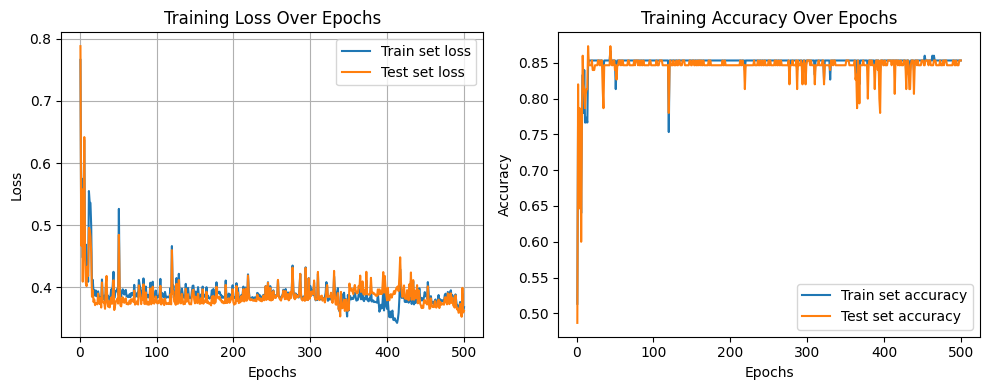

In [29]:
batch_size = 1

# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train, y_train, x_test, y_test),
    n_epochs=500,
    print_every=50,
    batch_size=batch_size
)

# plot all curves
plot_loss_acc(training_curve)

Epoch 50/500 | train loss: 0.3662 | train acc (%): 87.33 | test loss: 0.3580 | test acc (%): 88.00
Epoch 100/500 | train loss: 0.3218 | train acc (%): 88.00 | test loss: 0.3543 | test acc (%): 86.67
Epoch 150/500 | train loss: 0.3226 | train acc (%): 86.67 | test loss: 0.3625 | test acc (%): 85.33
Epoch 200/500 | train loss: 0.3136 | train acc (%): 87.33 | test loss: 0.3746 | test acc (%): 83.33
Epoch 250/500 | train loss: 0.3118 | train acc (%): 87.33 | test loss: 0.3919 | test acc (%): 83.33
Epoch 300/500 | train loss: 0.3268 | train acc (%): 85.33 | test loss: 0.4290 | test acc (%): 81.33
Epoch 350/500 | train loss: 0.3232 | train acc (%): 86.00 | test loss: 0.4537 | test acc (%): 81.33
Epoch 400/500 | train loss: 0.3219 | train acc (%): 86.00 | test loss: 0.4487 | test acc (%): 81.33
Epoch 450/500 | train loss: 0.3216 | train acc (%): 86.00 | test loss: 0.4698 | test acc (%): 81.33
Epoch 500/500 | train loss: 0.3781 | train acc (%): 85.33 | test loss: 0.3687 | test acc (%): 84.00


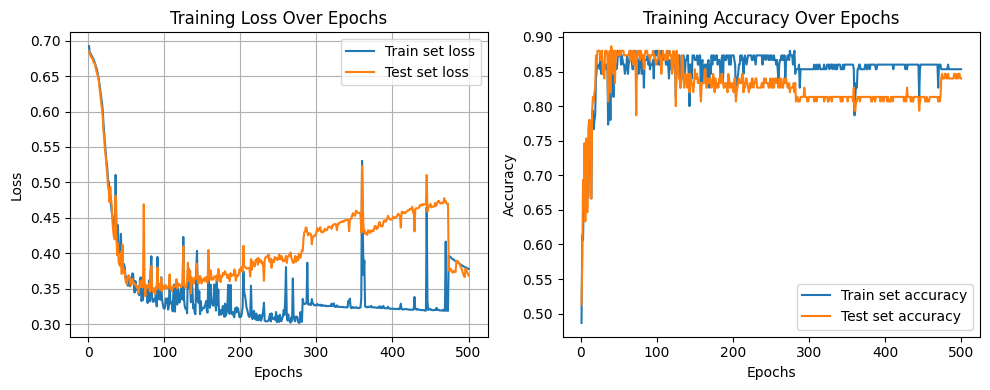

In [30]:
batch_size = 16

# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train, y_train, x_test, y_test),
    n_epochs=500,
    print_every=50,
    batch_size=batch_size
)

# plot all curves
plot_loss_acc(training_curve)

Epoch 50/500 | train loss: 0.5815 | train acc (%): 85.33 | test loss: 0.5741 | test acc (%): 87.33
Epoch 100/500 | train loss: 0.4395 | train acc (%): 87.33 | test loss: 0.4262 | test acc (%): 86.67
Epoch 150/500 | train loss: 0.3760 | train acc (%): 87.33 | test loss: 0.3619 | test acc (%): 87.33
Epoch 200/500 | train loss: 0.3531 | train acc (%): 87.33 | test loss: 0.3401 | test acc (%): 87.33
Epoch 250/500 | train loss: 0.3429 | train acc (%): 87.33 | test loss: 0.3316 | test acc (%): 88.00
Epoch 300/500 | train loss: 0.3326 | train acc (%): 88.00 | test loss: 0.3364 | test acc (%): 88.00
Epoch 350/500 | train loss: 0.3264 | train acc (%): 88.00 | test loss: 0.3344 | test acc (%): 88.00
Epoch 400/500 | train loss: 0.3209 | train acc (%): 88.00 | test loss: 0.3342 | test acc (%): 87.33
Epoch 450/500 | train loss: 0.3164 | train acc (%): 88.00 | test loss: 0.3345 | test acc (%): 85.33
Epoch 500/500 | train loss: 0.3126 | train acc (%): 88.00 | test loss: 0.3345 | test acc (%): 85.33


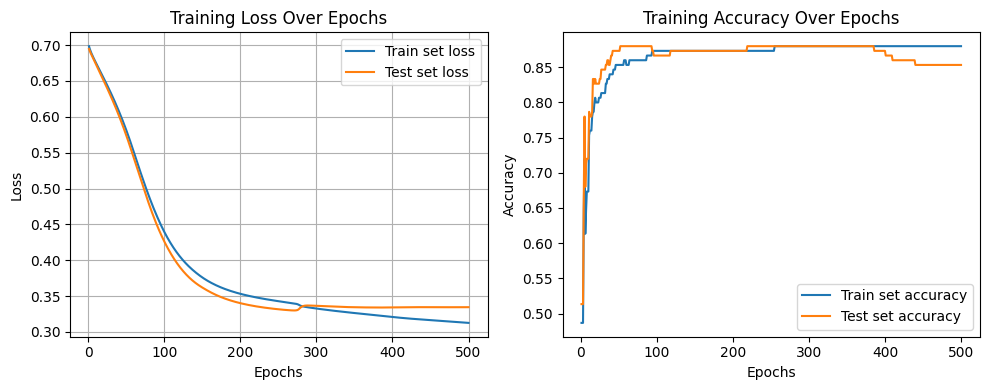

In [31]:
batch_size = len(y_train)

# create model, optimizer, and loss function
model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

# train the model
model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train, y_train, x_test, y_test),
    n_epochs=500,
    print_every=50,
    batch_size=batch_size
)

# plot all curves
plot_loss_acc(training_curve)

In general, using a larger batch size leads to smoother loss curves, because each gradient update is computed from more training examples and is therefore less noisy.

Training in a larger batch size is more efficient as we don't update the weights as frequent as when training in a smaller batch size.

### 5. Optimization Methods

The final major factor that we'd like to introduce is the optimizer. The optimizer is the the algorithm that updates the model parameters using the gradients.

Below, let's experiment with the following optimizers:
- Vanilla SGD
- SGD with momentum

**Vanilla SGD Optimizer**

Epoch 100/1000 | train loss: 0.6981 | train acc (%): 51.33 | test loss: 0.7003 | test acc (%): 48.67
Epoch 200/1000 | train loss: 0.6946 | train acc (%): 51.33 | test loss: 0.6964 | test acc (%): 48.67
Epoch 300/1000 | train loss: 0.6921 | train acc (%): 51.33 | test loss: 0.6937 | test acc (%): 48.67
Epoch 400/1000 | train loss: 0.6895 | train acc (%): 51.33 | test loss: 0.6907 | test acc (%): 48.67
Epoch 500/1000 | train loss: 0.6851 | train acc (%): 51.33 | test loss: 0.6860 | test acc (%): 49.33
Epoch 600/1000 | train loss: 0.6764 | train acc (%): 77.33 | test loss: 0.6764 | test acc (%): 80.00
Epoch 700/1000 | train loss: 0.6564 | train acc (%): 85.33 | test loss: 0.6547 | test acc (%): 84.67
Epoch 800/1000 | train loss: 0.6085 | train acc (%): 86.67 | test loss: 0.6033 | test acc (%): 88.00
Epoch 900/1000 | train loss: 0.5124 | train acc (%): 86.67 | test loss: 0.5021 | test acc (%): 87.33
Epoch 1000/1000 | train loss: 0.4060 | train acc (%): 86.67 | test loss: 0.3928 | test acc 

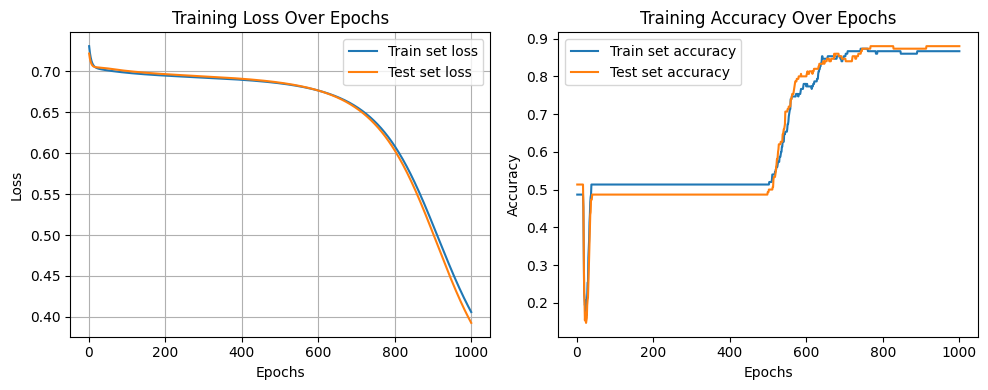

In [32]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=4, output_size=2)
loss_function = nn.CrossEntropyLoss()

# set up optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=1000,
    print_every=100
)

plot_loss_acc(training_curve)

**SGD Optimizer with Momentum**

Use `momentum=0.9`

Epoch 100/1000 | train loss: 0.2896 | train acc (%): 88.00 | test loss: 0.3024 | test acc (%): 83.33
Epoch 200/1000 | train loss: 0.2876 | train acc (%): 87.33 | test loss: 0.2955 | test acc (%): 84.67
Epoch 300/1000 | train loss: 0.2828 | train acc (%): 88.00 | test loss: 0.2910 | test acc (%): 84.67
Epoch 400/1000 | train loss: 0.2521 | train acc (%): 88.67 | test loss: 0.2634 | test acc (%): 86.67
Epoch 500/1000 | train loss: 0.1463 | train acc (%): 94.00 | test loss: 0.1571 | test acc (%): 92.67
Epoch 600/1000 | train loss: 0.0768 | train acc (%): 96.67 | test loss: 0.0816 | test acc (%): 98.00
Epoch 700/1000 | train loss: 0.0567 | train acc (%): 96.67 | test loss: 0.0632 | test acc (%): 98.00
Epoch 800/1000 | train loss: 0.0484 | train acc (%): 98.00 | test loss: 0.0574 | test acc (%): 98.00
Epoch 900/1000 | train loss: 0.0438 | train acc (%): 99.33 | test loss: 0.0559 | test acc (%): 98.00
Epoch 1000/1000 | train loss: 0.0407 | train acc (%): 99.33 | test loss: 0.0566 | test acc 

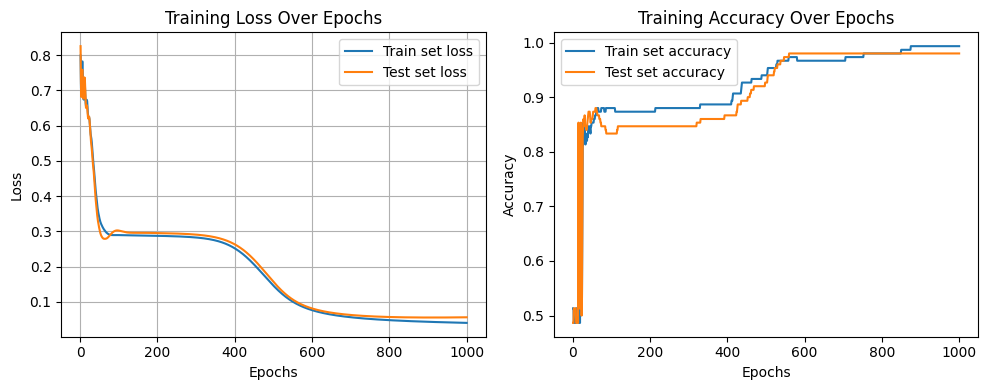

In [33]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=16, output_size=2)
loss_function = nn.CrossEntropyLoss()

# set up SGD with momentum=0.9
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=1000,
    print_every=100
)

plot_loss_acc(training_curve)

With `momentum=0.9`, the loss drops faster.

## Overfitting \& Underfitting

***Underfitting*** and ***overfitting*** are common issues in training. Before learning how to fix these issues, we need to learn how to **recognize** them from learning curves. Helpful visualizations are the following:
- Training loss vs. test loss
- Training performance vs. test performance (e.g., accuracy)

### Underfitting

A common way to diaganose underfitting is to compare training and validation performance. If both are low, it’s a sign of underfitting.

There can be many reasons for underfitting, for instance,
- model complexity too low
- training set too small
- insufficient number of training epochs

To understand what the problem is, we can tweak these factors and see if there's improvement.



For instance, what happens when we use `hidden_size = 2`?


Epoch 500/5000 | train loss: 0.6868 | train acc (%): 51.33 | test loss: 0.6876 | test acc (%): 48.67
Epoch 1000/5000 | train loss: 0.4974 | train acc (%): 86.67 | test loss: 0.4889 | test acc (%): 85.33
Epoch 1500/5000 | train loss: 0.3087 | train acc (%): 88.00 | test loss: 0.3121 | test acc (%): 84.67
Epoch 2000/5000 | train loss: 0.3009 | train acc (%): 87.33 | test loss: 0.3109 | test acc (%): 84.67
Epoch 2500/5000 | train loss: 0.2987 | train acc (%): 87.33 | test loss: 0.3088 | test acc (%): 84.67
Epoch 3000/5000 | train loss: 0.2968 | train acc (%): 87.33 | test loss: 0.3061 | test acc (%): 84.67
Epoch 3500/5000 | train loss: 0.2953 | train acc (%): 87.33 | test loss: 0.3038 | test acc (%): 84.67
Epoch 4000/5000 | train loss: 0.2940 | train acc (%): 87.33 | test loss: 0.3020 | test acc (%): 84.67
Epoch 4500/5000 | train loss: 0.2929 | train acc (%): 87.33 | test loss: 0.3007 | test acc (%): 84.67
Epoch 5000/5000 | train loss: 0.2920 | train acc (%): 87.33 | test loss: 0.2998 | t

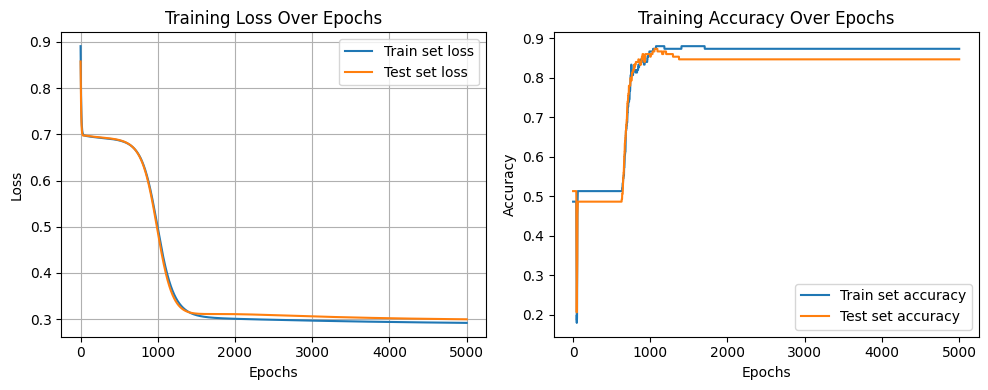

In [34]:
hidden_size = 2 # a small hidden size

model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=5000,
    print_every=500
)

plot_loss_acc(training_curve)

Both train and test accuracies are stuck under 90%. In this case, the model is underfitting.

### Overfitting

A common diagnosis of overfitting is a (1) train loss significantly lower than test loss and (2) test loss growing over time while training loss keeps dropping.  There can be many reasons for overfitting, for instance,

- model complexity too high
- training set too small
- training for too many epochs

Again, change the above settings and find out what's causing the overfitting of your model.

In this example, we use `hidden_size = 128` for the model. We can see the model **complexity is too high**, with the parameters converging well on the train set alongside performance worsening on the test set.


Epoch 3000/30000 | train loss: 0.2786 | train acc (%): 87.33 | test loss: 0.2857 | test acc (%): 85.33
Epoch 6000/30000 | train loss: 0.0802 | train acc (%): 98.00 | test loss: 0.0911 | test acc (%): 98.00
Epoch 9000/30000 | train loss: 0.0368 | train acc (%): 98.67 | test loss: 0.0560 | test acc (%): 98.00
Epoch 12000/30000 | train loss: 0.0249 | train acc (%): 99.33 | test loss: 0.0576 | test acc (%): 98.00
Epoch 15000/30000 | train loss: 0.0177 | train acc (%): 99.33 | test loss: 0.0591 | test acc (%): 98.00
Epoch 18000/30000 | train loss: 0.0136 | train acc (%): 100.00 | test loss: 0.0587 | test acc (%): 98.00
Epoch 21000/30000 | train loss: 0.0111 | train acc (%): 100.00 | test loss: 0.0597 | test acc (%): 98.00
Epoch 24000/30000 | train loss: 0.0092 | train acc (%): 100.00 | test loss: 0.0620 | test acc (%): 98.00
Epoch 27000/30000 | train loss: 0.0079 | train acc (%): 100.00 | test loss: 0.0649 | test acc (%): 98.00
Epoch 30000/30000 | train loss: 0.0067 | train acc (%): 100.00 

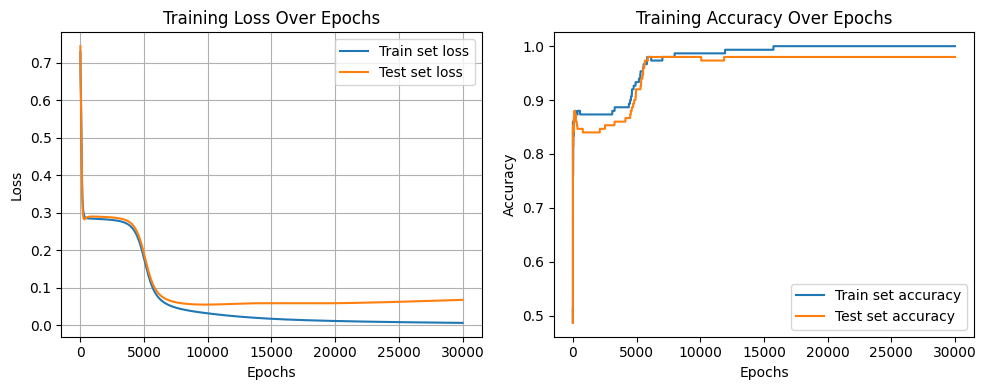

In [35]:
hidden_size = 128 # a large hidden size

model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=30000,
    print_every=3000)

plot_loss_acc(training_curve)

This time, we are able to achieve a much better accuracy score on the train set. However, we noticed that after around 10,000 to 15,000 epochs, the **test loss started to increase** while the train loss was still consistently dropping as we expected. Around the same time, the test accuracy stopped improving as the train accuracy kept moving toward 100%.

This tells us that the model is **overfitting to the train set**.



### Early Stopping

Early stopping is a practical way to choose a good stopping point without manually guessing the “right” number of `epochs`. It helps you avoid both:

- Underfitting (stopping too early, before the model has learned enough), and
- Overfitting (training too long, after the model starts memorizing the training set).

A common workflow is to set a fairly large `n_epochs`, then let early stopping decide when to stop.

Let's upgrade our `train_model(...)` function with the early stopping feature:

- We monitor `test_loss` after each epoch by computing in `model.eval()` mode with `torch.no_grad()`.

- If `test_loss` improves, we:
  - update `best_test_loss`
  - save a copy of the current best model weights using `copy.deepcopy(model.state_dict())`
  - reset the “no improvement” counter

- If `test_loss` does not improve for `patience` consecutive epochs, we stop training early.

After training finishes, we load the best saved weights, so the returned model is the best-performing one on the test set.

Optionally, you can also set a small `min_delta` so that only meaningful decreases in `test_loss` count as an improvement.

Now, let's upgrade our training function! Pay attention to the comments in the cell below that point you to the early stopping implementation:

In [36]:
import copy
import torch

def train_model(model, optimizer, loss_function, dataset,
                n_epochs=10000,
                print_every=1000,
                early_stopping=True,
                patience=5000,
                min_delta=1e-2):

    x_train, y_train, x_test, y_test = dataset
    epochs, losses_train, losses_test, acc_train, acc_test = [], [], [], [], []

    # -- Early Stopping Setup --
    best_test_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    best_epoch = -1
    no_improvement_count = 0

    for epoch in range(n_epochs):
        model.train()

        logits_train = model(x_train)
        loss = loss_function(logits_train, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_train_eval = model(x_train)
            train_loss = loss_function(logits_train_eval, y_train).item()
            pred_train = torch.argmax(logits_train_eval, dim=1)
            train_acc = (pred_train == y_train).float().mean().item()

            logits_test = model(x_test)
            test_loss = loss_function(logits_test, y_test).item()
            pred_test = torch.argmax(logits_test, dim=1)
            test_acc = (pred_test == y_test).float().mean().item()

        if epoch % print_every == print_every - 1:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"train loss: {train_loss:.4f} | train acc (%): {train_acc*100:.2f} | "
                  f"test loss: {test_loss:.4f} | test acc (%): {test_acc*100:.2f}")

        epochs.append(epoch + 1)
        losses_train.append(train_loss)
        losses_test.append(test_loss)
        acc_train.append(train_acc)
        acc_test.append(test_acc)

        # -- Early Stopping logic --
        if early_stopping:
            # Improvement means test_loss got smaller by at least min_delta
            if test_loss < best_test_loss - min_delta:
                best_test_loss = test_loss
                best_model_weights = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1
                no_improvement_count = 0
            else:
                no_improvement_count += 1
                if no_improvement_count >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1}. "
                          f"Best epoch was {best_epoch} with test loss {best_test_loss:.4f}.")
                    break

    # -- Reload Model --
    # load best model weights (so returned model is the best one)
    if early_stopping:
        model.load_state_dict(best_model_weights)

    training_curve = {
        "epochs": epochs,
        "losses_train": losses_train,
        "losses_test": losses_test,
        "acc_train": acc_train,
        "acc_test": acc_test,
    }

    return model, training_curve


Epoch 3000/30000 | train loss: 0.2808 | train acc (%): 87.33 | test loss: 0.2875 | test acc (%): 84.67
Epoch 6000/30000 | train loss: 0.1066 | train acc (%): 96.67 | test loss: 0.1153 | test acc (%): 97.33
Epoch 9000/30000 | train loss: 0.0406 | train acc (%): 98.67 | test loss: 0.0584 | test acc (%): 98.00
Epoch 12000/30000 | train loss: 0.0292 | train acc (%): 98.67 | test loss: 0.0589 | test acc (%): 97.33
Early stopping triggered at epoch 12585. Best epoch was 7585 with test loss 0.0652.


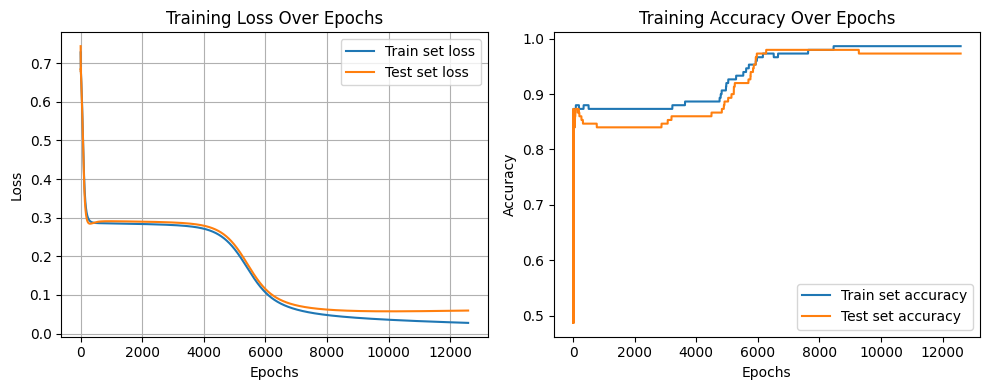

In [37]:
hidden_size = 128

model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=30000,
    print_every=3000,
    early_stopping=True,
    patience=5000,
    min_delta=1e-2
)

plot_loss_acc(training_curve)

We have successfully stopped the training around 10,000 to 15,000 epochs!

### Checkpoint Reading and Writing

So far, we’ve been training models and keeping their parameters only in memory (i.e., the current runtime). In practice, that’s risky: **if your session crashes, disconnects, or you simply want to reuse a trained model later, you need to save checkpoints to disk**.

In PyTorch, the standard way to save a model is to save its state dictionary:
```
model.state_dict()
```

It stores all learnable parameters (i.e., weights and biases).
- You can write it to a file with [`torch.save(...)`](https://docs.pytorch.org/docs/main/generated/torch.save.html)
- You can load it back later with [`torch.load(...)`](https://docs.pytorch.org/docs/stable/generated/torch.load.html) and `model.load_state_dict(...)`. Please explore [this link](https://docs.pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html) to learn more about saving and loading models.

A common pattern is:
- Save checkpoints periodically (e.g., every 100 epochs), or whenever performance improves. Carefully leverage the time for saving a model and the time for your training to find an optimal period.
- When using early stopping, it’s especially useful to save the current best model whenever `test_loss` improves.
- To keep things simple, we’ll save to a single filename (e.g., `"best_model.pt"`), so each new best model overwrites the previous one.

**Saving a checkpoint**
```
torch.save(model.state_dict(), "best_model.pt")
```
**Loading a checkpoint**
```
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
```


Don't forget that we are now using Colab instead of a local resource. To save/load any files, we need to run the following cell to connect Google Drive to this script:

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Write a model checkpoint:**

In [42]:
model_path = '/content/drive/My Drive/Colab Notebooks/CSCI 5922/demo_model.pt'

Let's update the training function again with checkpoint saving!

In [40]:
def train_model(model, optimizer, loss_function, dataset,
                n_epochs=10000, print_every=1000,
                early_stopping=True, patience=1000, min_delta=0.0,
                save_best_path=None):
    x_train, y_train, x_test, y_test = dataset
    epochs, losses_train, losses_test, acc_train, acc_test = [], [], [], [], []

    best_test_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    best_epoch = -1
    no_improvement_count = 0

    for epoch in range(n_epochs):
        model.train()

        logits_train = model(x_train)
        loss = loss_function(logits_train, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_train_eval = model(x_train)
            train_loss = loss_function(logits_train_eval, y_train).item()
            train_acc = (logits_train_eval.argmax(dim=1) == y_train).float().mean().item()

            logits_test = model(x_test)
            test_loss = loss_function(logits_test, y_test).item()
            test_acc = (logits_test.argmax(dim=1) == y_test).float().mean().item()

        if epoch % print_every == print_every - 1:
            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"train loss: {train_loss:.4f} | train acc: {train_acc*100:.2f}% | "
                  f"test loss: {test_loss:.4f} | test acc: {test_acc*100:.2f}%")

        epochs.append(epoch + 1)
        losses_train.append(train_loss)
        losses_test.append(test_loss)
        acc_train.append(train_acc)
        acc_test.append(test_acc)

        improved = test_loss < best_test_loss - min_delta
        if improved:
            best_test_loss = test_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            no_improvement_count = 0

            # Save checkpoint on disk (single filename)
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

        else:
            no_improvement_count += 1
            if early_stopping and no_improvement_count >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. "
                      f"Best epoch was {best_epoch} with test loss {best_test_loss:.4f}.")
                break

    # load best model weights (so returned model is best by test loss)
    model.load_state_dict(best_model_weights)

    training_curve = {
        "epochs": epochs,
        "losses_train": losses_train,
        "losses_test": losses_test,
        "acc_train": acc_train,
        "acc_test": acc_test,
    }

    return model, training_curve

Let's try it again -- this time, the best model should be saved to your `checkpoint_path`:

Epoch 3000/30000 | train loss: 0.2822 | train acc: 87.33% | test loss: 0.2873 | test acc: 84.67%
Epoch 6000/30000 | train loss: 0.1286 | train acc: 95.33% | test loss: 0.1397 | test acc: 94.00%
Epoch 9000/30000 | train loss: 0.0415 | train acc: 98.67% | test loss: 0.0577 | test acc: 98.00%
Epoch 12000/30000 | train loss: 0.0299 | train acc: 98.67% | test loss: 0.0563 | test acc: 97.33%
Early stopping triggered at epoch 12871. Best epoch was 7871 with test loss 0.0636.


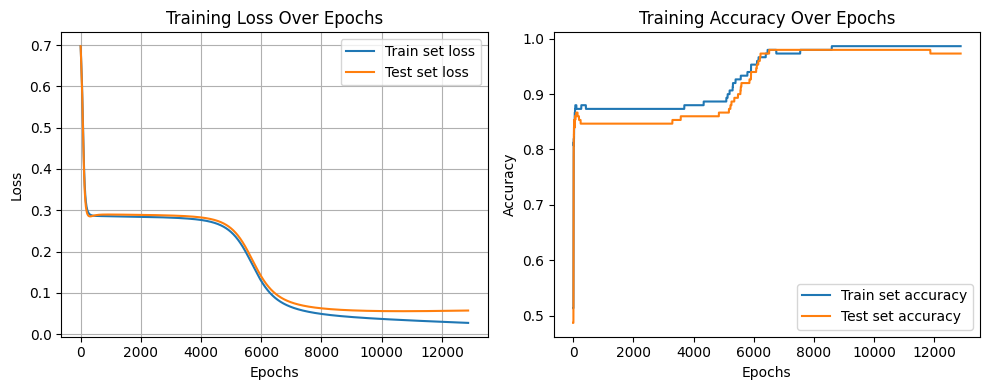

In [43]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=128, output_size=2)
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_function = nn.CrossEntropyLoss()

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=30000,
    print_every=3000,
    early_stopping=True,
    patience=5000,
    min_delta=1e-2,
    save_best_path=model_path # set up checkpoint path
)

plot_loss_acc(training_curve)

Now, let's try loading the best model from Google Drive and evaluate it on the test set.

In [44]:
# create a fresh model with the same architecture
best_model = MLPMultiClassClassifier(input_size=2, hidden_size=128, output_size=2)

# load the best saved weights
best_model.load_state_dict(torch.load(model_path))
best_model.eval()

# predict on the test set
with torch.no_grad():
    logits_test = best_model(x_test_std)
    y_pred_test = torch.argmax(logits_test, dim=1)

    test_acc = (y_pred_test == y_test).float().mean().item()

print(f"Best saved model test accuracy: {test_acc*100:.2f}%")
print("First 10 predictions:", y_pred_test[:10].tolist())
print("First 10 ground truth:", y_test[:10].tolist())


Best saved model test accuracy: 98.00%
First 10 predictions: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1]
First 10 ground truth: [1, 1, 0, 0, 0, 1, 1, 1, 0, 0]


### L2 Regularization

L2 regularization is an effective solution for overfitting. The simplest way to add L2 regularization is through the builtin setup of the optimizer. In [`optim.SGD()`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html), the argument `weight_decay` helps by adding the penalty of L2. The larger the value is, the more penalty is applied to your loss.

Optionally, you can also always add the penalty **manually**, which will be something like this:
```
reg_loss = 0
for param in model.parameters():
    reg_loss += torch.sum(param**2)  # or param.norm(2)

# Weighted L2 penalty
lambda_l2 = 1e-4
loss = loss + lambda_l2 * reg_loss
```

Let's turn off the early stopping feature and compare the training curves of this experience **with L2** to the **overfitting** model we trained earlier.

Epoch 3000/30000 | train loss: 0.2813 | train acc: 88.00% | test loss: 0.2866 | test acc: 84.67%
Epoch 6000/30000 | train loss: 0.1010 | train acc: 96.67% | test loss: 0.1095 | test acc: 97.33%
Epoch 9000/30000 | train loss: 0.0427 | train acc: 98.67% | test loss: 0.0571 | test acc: 98.00%
Epoch 12000/30000 | train loss: 0.0309 | train acc: 98.67% | test loss: 0.0535 | test acc: 97.33%
Epoch 15000/30000 | train loss: 0.0228 | train acc: 99.33% | test loss: 0.0511 | test acc: 97.33%
Epoch 18000/30000 | train loss: 0.0177 | train acc: 99.33% | test loss: 0.0484 | test acc: 98.00%
Epoch 21000/30000 | train loss: 0.0147 | train acc: 100.00% | test loss: 0.0478 | test acc: 98.00%
Epoch 24000/30000 | train loss: 0.0128 | train acc: 100.00% | test loss: 0.0483 | test acc: 98.00%
Epoch 27000/30000 | train loss: 0.0115 | train acc: 100.00% | test loss: 0.0494 | test acc: 98.00%
Epoch 30000/30000 | train loss: 0.0105 | train acc: 100.00% | test loss: 0.0507 | test acc: 98.00%


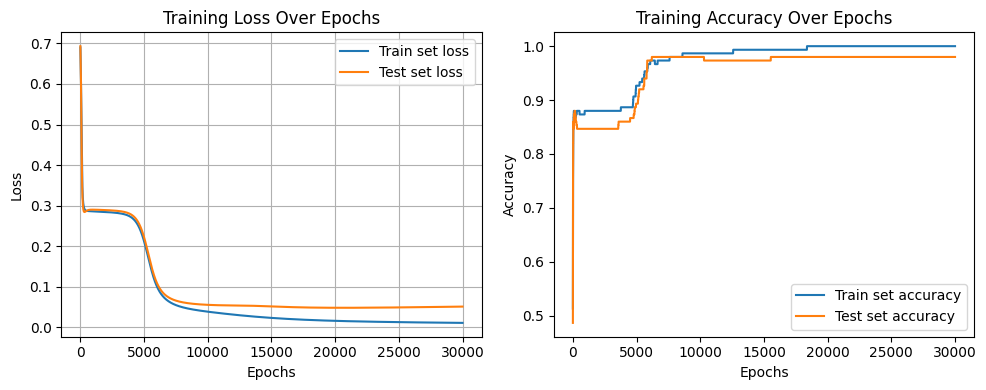

In [45]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=128, output_size=2)
loss_function = nn.CrossEntropyLoss()

# Add L2 loss
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=30000,
    print_every=3000,
    early_stopping=False
)

plot_loss_acc(training_curve)

We can see that the L2 loss helps control the overfitting trend by observing the changes in test loss. By increaing the L2 loss, `weight_decay`, we can see the overfitting effect being further improved.

However, when the L2 loss is too large, it can create too much noise and cause underfitting:

Epoch 3000/30000 | train loss: 0.3011 | train acc: 87.33% | test loss: 0.2940 | test acc: 85.33%
Epoch 6000/30000 | train loss: 0.3010 | train acc: 87.33% | test loss: 0.2939 | test acc: 85.33%
Epoch 9000/30000 | train loss: 0.3009 | train acc: 87.33% | test loss: 0.2938 | test acc: 85.33%
Epoch 12000/30000 | train loss: 0.3009 | train acc: 87.33% | test loss: 0.2937 | test acc: 85.33%
Epoch 15000/30000 | train loss: 0.3009 | train acc: 87.33% | test loss: 0.2937 | test acc: 85.33%
Epoch 18000/30000 | train loss: 0.3008 | train acc: 87.33% | test loss: 0.2936 | test acc: 85.33%
Epoch 21000/30000 | train loss: 0.3008 | train acc: 87.33% | test loss: 0.2936 | test acc: 85.33%
Epoch 24000/30000 | train loss: 0.3008 | train acc: 87.33% | test loss: 0.2936 | test acc: 85.33%
Epoch 27000/30000 | train loss: 0.3007 | train acc: 87.33% | test loss: 0.2935 | test acc: 85.33%
Epoch 30000/30000 | train loss: 0.3007 | train acc: 87.33% | test loss: 0.2935 | test acc: 85.33%


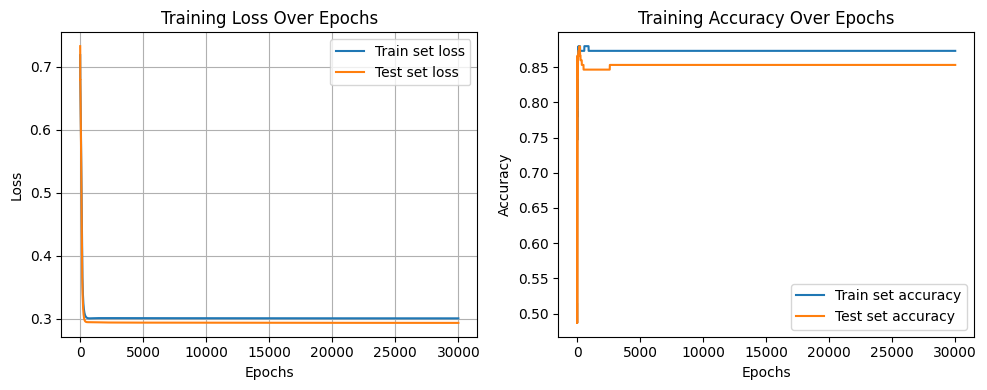

In [46]:
model = MLPMultiClassClassifier(input_size=2, hidden_size=hidden_size, output_size=2)
loss_function = nn.CrossEntropyLoss()

# increase L2 loss
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-2)

model, training_curve = train_model(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    dataset=(x_train_std, y_train, x_test_std, y_test),
    n_epochs=30000,
    print_every=3000,
    early_stopping=False
)

plot_loss_acc(training_curve)


## Review

Diagnosing the training issues and finding a suitable solution is a crucial skill to learn for neural networks training. Today, we introduced underfitting and overfitting effects, and we practiced implemeting early stopping and L2 loss to handle these effects. We also explored different methods to enhance the trianing stability, including standardization, initialization, and optimization.

Here is a practice that you can try:
- **Increase the model depth**: train models with (1) 5 layers and 2 nodes per layer, and (2) 5 layers and 128 nodes per layer. What do you see in the trends of these two models? Do you see overfitting or underfitting?



For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley